INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 41 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'D', 'E', 'H', 'I', 'M', 'a', 'b', 'c', 'comma', 'e', 'eight', 'f', 'five', 'four', 'h', 'i', 'k', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'q', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 15, 17, 19, 20, 21, 22, 23, 24, 2

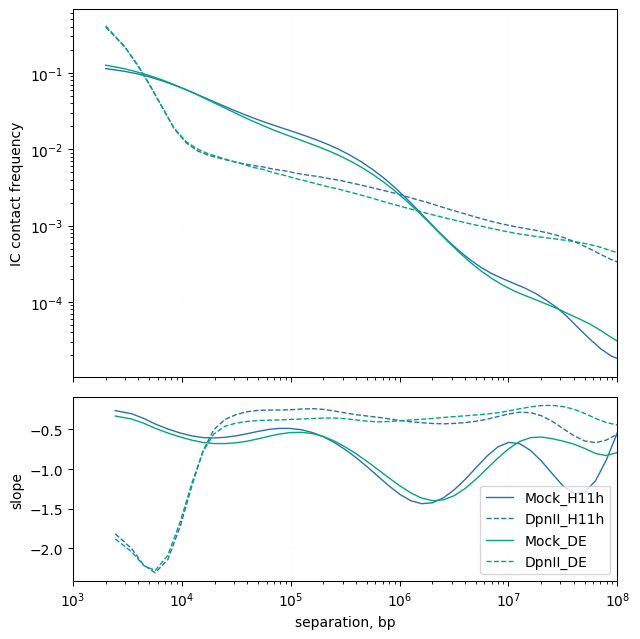

In [45]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#plt.style.use('seaborn-poster')
import numpy as np
import pandas as pd

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.1'):
    raise AssertionError("tutorials rely on cooltools version 0.5.1 or higher,"+
                         "please check your cooltools version and update to the latest")

#naming 
#pathDir = "/home/denis.lafontaine-umw/LC_HiC/distiller_runs/20241022b_TD_U1_reps_partial_exclude1kb_hg38/results/coolers_library"
outDataDir1 = "/home/denis.lafontaine-umw/LC_HiC/distiller_runs/20241122_TD1_PI_U2OS_Hap1Rbp1_Det_remap_exclude1kb_hg38/analysis/scaling"

conditions = [
    'Mock_H11h',
    'DpnII_H11h',
    'Mock_DE',
    'DpnII_DE'  
]


long_names = {
    'Mock_H11h' : '/MyPath/DL-20250820-LCHCSeq-H1ESC-240mPD-Mock-R4-T1',
    'DpnII_H11h' : '/MyPath/DL-20250820-LCHCSeq-H1ESC-60mPDp25-DpnII-R3-T1',
    'Mock_DE' : '/MyPath/DL-20260616-LCHCSeq-DE-120mPD-Mock-R2-T1',
    'DpnII_DE' : '/MyPath/DL-20260616-LCHCSeq-DE-120mPD-DpnII-R2-T1'
}

coolerfile = {}
for cond in conditions:
    coolerfile[cond] = '{}__hg38.hg38.exclude1kb.1000.mcool::resolutions/1000'.format(long_names[cond])

clrs = {}
for i in conditions:
    clrs[i] = cooler.Cooler(coolerfile[i])

# Use bioframe to fetch the genomic features from the UCSC.

hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
hg38_arms = bioframe.make_chromarms(hg38_chromsizes,  hg38_cens)

hg38_arms = hg38_arms[hg38_arms.chrom.isin(clrs[cond].chromnames)].reset_index(drop=True)


cvd = {}
# cvd == contacts-vs-distance
for cond in conditions:
    cvd[cond] = cooltools.expected_cis(
        clr=clrs[cond],
        view_df=hg38_arms,
        smooth=False,
        aggregate_smoothed=False,
        nproc=3 #if you do not have multiple cores available, set to 1
        )

from cooltools.api.expected import logbin_expected
from cooltools.api.expected import logbin_expected, combine_binned_expected

binned_exp={}
binned_slope={}
bins={}
scal={}
der={}
files_pass = []


# We need to logbin expected first - using default 10 bins per order magnitude
for cond in conditions:
    binned_exp[cond], binned_slope[cond], bins[cond] = logbin_expected(cvd[cond])

    scal[cond], der[cond] = combine_binned_expected(binned_exp[cond], binned_slope[cond], spread_funcs="logstd")

b= [0, 1,2,3]
conds = [conditions[i] for i in b]

####### Plot 
colors = {
    'Mock_H11h': '#2C6FB5',
    'DpnII_H11h': '#2C6FB5',
    'Mock_DE': '#00A878',
    'DpnII_DE': '#00A878',

}

styles = {
        'Mock_H11h': '-',
    'DpnII_H11h': '--',
    'Mock_DE': '-',
    'DpnII_DE': '--',
    # '--' dashed, '-.' dash-dot, ':' dotted
}


import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['axes.linewidth']    = 0.75
mpl.rcParams['xtick.major.width'] = 0.75
mpl.rcParams['ytick.major.width'] = 0.75
mpl.rcParams['grid.linewidth']    = 0.01
mpl.rcParams['lines.linewidth']   = 1 

f, axs = plt.subplots(
    figsize=(6.5, 6.5),          # overall canvas
    nrows=2,
    gridspec_kw={'height_ratios': [4, 2]},   # top:bottom height ratio
    sharex=True)

ax = axs[0]
for cond in conds:
    ax.loglog(
        scal[cond]["dist.avg"]*1000,
        scal[cond]['balanced.avg']/np.nansum(scal[cond]["balanced.avg"]),
        color=colors[cond],
        linestyle=styles[cond],
    )
ax.set(ylabel='IC contact frequency', xlim=(1e3, 1e8))
ax.grid()

ax = axs[1]
for cond in conds:
    ax.semilogx(
        der[cond]['dist.avg']*1000,
        der[cond]['slope'],
        color=colors[cond],
        linestyle=styles[cond],
        label=cond
    )
ax.set(xlabel='separation, bp', ylabel='slope')
ax.grid()

plt.legend()
plt.tight_layout()

f.savefig(
    'H11hvsDER2.kb.scaling.pdf',
    transparent=True,
    bbox_inches='tight',   # trims excess whitespace
)

INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 40 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'H', 'I', 'M', 'a', 'b', 'c', 'comma', 'e', 'eight', 'f', 'five', 'four', 'i', 'k', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'q', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26

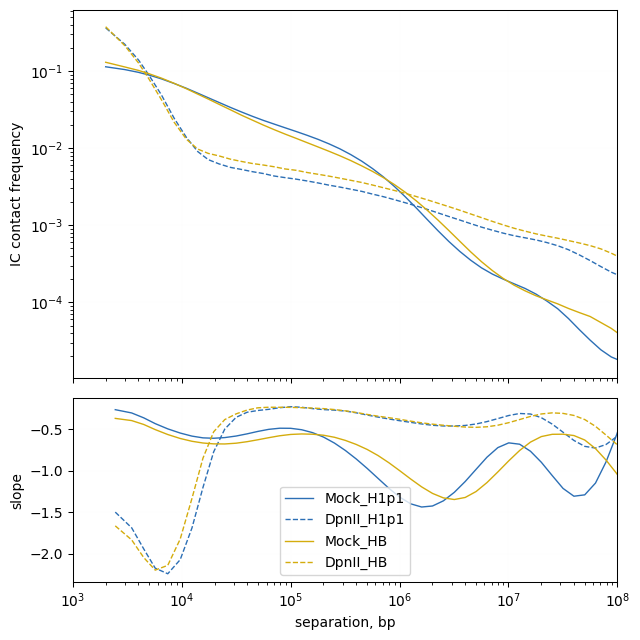

In [47]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#plt.style.use('seaborn-poster')
import numpy as np
import pandas as pd

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.1'):
    raise AssertionError("tutorials rely on cooltools version 0.5.1 or higher,"+
                         "please check your cooltools version and update to the latest")

#naming 
#pathDir = "/home/denis.lafontaine-umw/LC_HiC/distiller_runs/20241022b_TD_U1_reps_partial_exclude1kb_hg38/results/coolers_library"
outDataDir1 = "/home/denis.lafontaine-umw/LC_HiC/distiller_runs/20241122_TD1_PI_U2OS_Hap1Rbp1_Det_remap_exclude1kb_hg38/analysis/scaling"

conditions = [
    'Mock_H1p1',
    'DpnII_H1p1',
    'Mock_HB',
    'DpnII_HB'  
]


long_names = {
    'Mock_H1p1' : '/MyPath/DL-20250820-LCHCSeq-H1ESC-240mPD-Mock-R4-T1',
    'DpnII_H1p1' : '/MyPath/DL-20250820-LCHCSeq-H1ESC-60mPDp10-DpnII-R3-T1',
    'Mock_HB' : '/MyPath/DL-20250326-LCHCSeq-HB-2hPD-Mock-R2-T1',
    'DpnII_HB' : '/MyPath/DL-20250326-LCHCSeq-HB-2hPD-DpnII-R2-T1'
}

coolerfile = {}
for cond in conditions:
    coolerfile[cond] = '{}__hg38.hg38.exclude1kb.1000.mcool::resolutions/1000'.format(long_names[cond])

#coolerfile = '{}/HBHiC-K562-MN-Dp-2__hg19.hg19.exclude1kb.1000.mcool::resolutions/1000'.format(pathDir)
clrs = {}
for i in conditions:
    clrs[i] = cooler.Cooler(coolerfile[i])
#clrs = cooler.Cooler(coolerfile)

# Use bioframe to fetch the genomic features from the UCSC.

hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
hg38_arms = bioframe.make_chromarms(hg38_chromsizes,  hg38_cens)

#indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21]

#GOOD_CHROMS = [hg19_chromsizes.index[index] for index in indices]
#GOOD_CHROMS = list(hg19_chromsizes.index[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21])
# select only those chromosomes available in cooler
hg38_arms = hg38_arms[hg38_arms.chrom.isin(clrs[cond].chromnames)].reset_index(drop=True)


cvd = {}
# cvd == contacts-vs-distance
for cond in conditions:
    cvd[cond] = cooltools.expected_cis(
        clr=clrs[cond],
        view_df=hg38_arms,
        smooth=False,
        aggregate_smoothed=False,
        nproc=3 #if you do not have multiple cores available, set to 1
        )

from cooltools.api.expected import logbin_expected
from cooltools.api.expected import logbin_expected, combine_binned_expected

binned_exp={}
binned_slope={}
bins={}
scal={}
der={}
files_pass = []


# We need to logbin expected first - using default 10 bins per order magnitude
for cond in conditions:
    binned_exp[cond], binned_slope[cond], bins[cond] = logbin_expected(cvd[cond])

    scal[cond], der[cond] = combine_binned_expected(binned_exp[cond], binned_slope[cond], spread_funcs="logstd")

b= [0, 1,2,3]
conds = [conditions[i] for i in b]

####### Plot 
colors = {
    'Mock_H1p1': '#2C6FB5',
    'DpnII_H1p1': '#2C6FB5',
    'Mock_HB': '#D4AC0D',
    'DpnII_HB': '#D4AC0D',

}

styles = {
        'Mock_H1p1': '-',
    'DpnII_H1p1': '--',
    'Mock_HB': '-',
    'DpnII_HB': '--',
    # '--' dashed, '-.' dash-dot, ':' dotted
}


import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['axes.linewidth']    = 0.75
mpl.rcParams['xtick.major.width'] = 0.75
mpl.rcParams['ytick.major.width'] = 0.75
mpl.rcParams['grid.linewidth']    = 0.01
mpl.rcParams['lines.linewidth']   = 1 

f, axs = plt.subplots(
    figsize=(6.5, 6.5),          # overall canvas
    nrows=2,
    gridspec_kw={'height_ratios': [4, 2]},   # top:bottom height ratio
    sharex=True)

ax = axs[0]
for cond in conds:
    ax.loglog(
        scal[cond]["dist.avg"]*1000,
        scal[cond]['balanced.avg']/np.nansum(scal[cond]["balanced.avg"]),
        color=colors[cond],
        linestyle=styles[cond],
    )
ax.set(ylabel='IC contact frequency', xlim=(1e3, 1e8))
ax.grid()

ax = axs[1]
for cond in conds:
    ax.semilogx(
        der[cond]['dist.avg']*1000,
        der[cond]['slope'],
        color=colors[cond],
        linestyle=styles[cond],
        label=cond
    )
ax.set(xlabel='separation, bp', ylabel='slope')
ax.grid()

plt.legend()
plt.tight_layout()

f.savefig(
    'H1p1vsHBR2.kb.scaling.pdf',
    transparent=True,
    bbox_inches='tight',   # trims excess whitespace
)

INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 40 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'D', 'H', 'I', 'M', 'a', 'b', 'c', 'comma', 'e', 'eight', 'f', 'five', 'four', 'i', 'k', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'q', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26

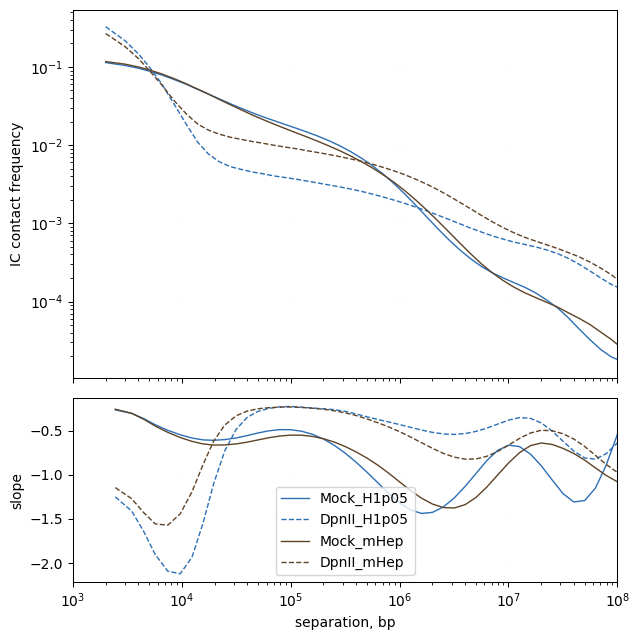

In [48]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#plt.style.use('seaborn-poster')
import numpy as np
import pandas as pd

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.1'):
    raise AssertionError("tutorials rely on cooltools version 0.5.1 or higher,"+
                         "please check your cooltools version and update to the latest")

#naming 
#pathDir = "/home/denis.lafontaine-umw/LC_HiC/distiller_runs/20241022b_TD_U1_reps_partial_exclude1kb_hg38/results/coolers_library"
outDataDir1 = "/home/denis.lafontaine-umw/LC_HiC/distiller_runs/20241122_TD1_PI_U2OS_Hap1Rbp1_Det_remap_exclude1kb_hg38/analysis/scaling"

conditions = [
    'Mock_H1p05',
    'DpnII_H1p05',
    'Mock_mHep',
    'DpnII_mHep'  
]


long_names = {
    'Mock_H1p05' : '/MyPath/DL-20250820-LCHCSeq-H1ESC-240mPD-Mock-R4-T1',
    'DpnII_H1p05' : '/MyPath/DL-20250820-LCHCSeq-H1ESC-60mPDp05-DpnII-R3-T1',
    'Mock_mHep' : '/MyPath/DL-20250326-LCHCSeq-mHep-2hPD-Mock-R2-T1',
    'DpnII_mHep' : '/MyPath/DL-20250326-LCHCSeq-mHep-2hPD-DpnII-R2-T1'
}

coolerfile = {}
for cond in conditions:
    coolerfile[cond] = '{}__hg38.hg38.exclude1kb.1000.mcool::resolutions/1000'.format(long_names[cond])

#coolerfile = '{}/HBHiC-K562-MN-Dp-2__hg19.hg19.exclude1kb.1000.mcool::resolutions/1000'.format(pathDir)
clrs = {}
for i in conditions:
    clrs[i] = cooler.Cooler(coolerfile[i])
#clrs = cooler.Cooler(coolerfile)

# Use bioframe to fetch the genomic features from the UCSC.

hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
hg38_arms = bioframe.make_chromarms(hg38_chromsizes,  hg38_cens)

#indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21]

#GOOD_CHROMS = [hg19_chromsizes.index[index] for index in indices]
#GOOD_CHROMS = list(hg19_chromsizes.index[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21])
# select only those chromosomes available in cooler
hg38_arms = hg38_arms[hg38_arms.chrom.isin(clrs[cond].chromnames)].reset_index(drop=True)


cvd = {}
# cvd == contacts-vs-distance
for cond in conditions:
    cvd[cond] = cooltools.expected_cis(
        clr=clrs[cond],
        view_df=hg38_arms,
        smooth=False,
        aggregate_smoothed=False,
        nproc=3 #if you do not have multiple cores available, set to 1
        )

from cooltools.api.expected import logbin_expected
from cooltools.api.expected import logbin_expected, combine_binned_expected

binned_exp={}
binned_slope={}
bins={}
scal={}
der={}
files_pass = []


# We need to logbin expected first - using default 10 bins per order magnitude
for cond in conditions:
    binned_exp[cond], binned_slope[cond], bins[cond] = logbin_expected(cvd[cond])

    scal[cond], der[cond] = combine_binned_expected(binned_exp[cond], binned_slope[cond], spread_funcs="logstd")

b= [0, 1,2,3]
conds = [conditions[i] for i in b]

####### Plot 
colors = {
    'Mock_H1p05': '#2C6FB5',
    'DpnII_H1p05': '#2C6FB5',
    'Mock_mHep': '#5E4327',
    'DpnII_mHep': '#5E4327',

}

styles = {
        'Mock_H1p05': '-',
    'DpnII_H1p05': '--',
    'Mock_mHep': '-',
    'DpnII_mHep': '--',
    # '--' dashed, '-.' dash-dot, ':' dotted
}


import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['axes.linewidth']    = 0.75
mpl.rcParams['xtick.major.width'] = 0.75
mpl.rcParams['ytick.major.width'] = 0.75
mpl.rcParams['grid.linewidth']    = 0.01
mpl.rcParams['lines.linewidth']   = 1 

f, axs = plt.subplots(
    figsize=(6.5, 6.5),          # overall canvas
    nrows=2,
    gridspec_kw={'height_ratios': [4, 2]},   # top:bottom height ratio
    sharex=True)

ax = axs[0]
for cond in conds:
    ax.loglog(
        scal[cond]["dist.avg"]*1000,
        scal[cond]['balanced.avg']/np.nansum(scal[cond]["balanced.avg"]),
        color=colors[cond],
        linestyle=styles[cond],
    )
ax.set(ylabel='IC contact frequency', xlim=(1e3, 1e8))
ax.grid()

ax = axs[1]
for cond in conds:
    ax.semilogx(
        der[cond]['dist.avg']*1000,
        der[cond]['slope'],
        color=colors[cond],
        linestyle=styles[cond],
        label=cond
    )
ax.set(xlabel='separation, bp', ylabel='slope')
ax.grid()

plt.legend()
plt.tight_layout()

f.savefig(
    'H1p05vsmHepR1.kb.scaling.pdf',
    transparent=True,
    bbox_inches='tight',   # trims excess whitespace
)